In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sse_core.compiler.builder import SSECompiler
from sse_core.compiler.parser import SSEParser
from sse_core.compiler.units import E_CHARGE
from sse_core.solvers.gillespie import GillespieSolver

In [2]:
# Thermal voltage
V_THERMAL = 26.0e-3

# Paper parameters for the p-bit
C_G = 50.0e-18
C_O = 1.0e-2 * C_G
SLOPE_FACTOR = 1.0

# MOSFET parameters: these only set the time scale
V_THRESHOLD = 4.0 * V_THERMAL
T0 = 1.0e-9

I0 = (
    E_CHARGE
    / T0
    * np.exp(
        V_THRESHOLD
        / (SLOPE_FACTOR * V_THERMAL)
    )
)

# Figure 14(d): biased p-bit operating points

VDD_OVER_VT = 1.15
VBIAS_OVER_VT = 1.0

VIN_OVER_VT_CASES = [
    +1.4,
    -1.4,
]

VDD = VDD_OVER_VT * V_THERMAL
VSS = -VDD
VBIAS = VBIAS_OVER_VT * V_THERMAL

# Bias transistors are ten times weaker than the core transistors.
I0_BIAS = I0 / 10.0

print(f"Vdd / V_T       = {VDD_OVER_VT:.2f}")
print(f"Vdd             = {VDD:.6f} V")
print(f"Vss             = {VSS:.6f} V")
print(f"Vb / V_T        = {VBIAS_OVER_VT:.2f}")
print(f"Vb              = {VBIAS:.6f} V")
print(f"Vin / V_T cases = {VIN_OVER_VT_CASES}")
print(f"I0 core         = {I0:.6e} A")
print(f"I0 bias         = {I0_BIAS:.6e} A")


Vdd / V_T       = 1.15
Vdd             = 0.029900 V
Vss             = -0.029900 V
Vb / V_T        = 1.00
Vb              = 0.026000 V
Vin / V_T cases = [1.4, -1.4]
I0 core         = 8.747588e-09 A
I0 bias         = 8.747588e-10 A


In [3]:
from sse_core.devices.semiconductor import (
    grounded_body_mosfet_rates,
)

v_d = 0.4 * V_THERMAL
v_g = 1.4 * V_THERMAL
v_s = -0.2 * V_THERMAL
v_b = 0.0

n_forward, n_reverse = (
    grounded_body_mosfet_rates(
        v_d,
        v_g,
        v_s,
        v_b,
        I0_BIAS,
        +V_THRESHOLD,
        SLOPE_FACTOR,
        V_THERMAL,
        False,
    )
)

p_forward, p_reverse = (
    grounded_body_mosfet_rates(
        -v_d,
        -v_g,
        -v_s,
        v_b,
        I0_BIAS,
        -V_THRESHOLD,
        SLOPE_FACTOR,
        V_THERMAL,
        True,
    )
)

np.testing.assert_allclose(
    [n_forward, n_reverse],
    [p_reverse, p_forward],
    rtol=1.0e-12,
    atol=0.0,
)

np.testing.assert_allclose(
    np.log(n_forward / n_reverse),
    (v_d - v_s) / V_THERMAL,
    rtol=1.0e-12,
    atol=1.0e-12,
)

print("Grounded-body MOS mirror check: passed")
print("Grounded-body MOS LDB check:    passed")

Grounded-body MOS mirror check: passed
Grounded-body MOS LDB check:    passed


In [4]:
from textwrap import dedent


def build_biased_pbit_yaml(
    *,
    vin_over_vt,
    t_finish,
    seed,
):
    vin = vin_over_vt * V_THERMAL

    return dedent(
        f"""
        schema_version: "1.0.0"

        simulation:
          solver: "gillespie"
          t_finish: {t_finish:.17e}
          v_th: {V_THERMAL:.17e}
          seed: {seed}

        nodes:
          free:
            - name: "v1"
              initial_charge: 0

            - name: "v2"
              initial_charge: 0

          regulated:
            - name: "vdd"
              type: "constant"
              value: {VDD:.17e}

            - name: "vss"
              type: "constant"
              value: {VSS:.17e}

            - name: "vb"
              type: "constant"
              value: {VBIAS:.17e}

            - name: "vin"
              type: "constant"
              value: {vin:.17e}

            - name: "gnd"
              type: "constant"
              value: 0.0

        components:
          # ----------------------------------------------------------
          # Core capacitances
          # ----------------------------------------------------------

          - type: "capacitor"
            name: "Co_1_dd"
            terminals: ["v1", "vdd"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "Co_1_ss"
            terminals: ["v1", "vss"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "Co_2_dd"
            terminals: ["v2", "vdd"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "Co_2_ss"
            terminals: ["v2", "vss"]
            specs:
              capacitance: {C_O:.17e}

          # Inverter 1 input is v2.
          - type: "capacitor"
            name: "Cg_1_dd"
            terminals: ["v2", "vdd"]
            specs:
              capacitance: {C_G:.17e}

          - type: "capacitor"
            name: "Cg_1_ss"
            terminals: ["v2", "vss"]
            specs:
              capacitance: {C_G:.17e}

          # Inverter 2 input is v1.
          - type: "capacitor"
            name: "Cg_2_dd"
            terminals: ["v1", "vdd"]
            specs:
              capacitance: {C_G:.17e}

          - type: "capacitor"
            name: "Cg_2_ss"
            terminals: ["v1", "vss"]
            specs:
              capacitance: {C_G:.17e}

          # ----------------------------------------------------------
          # Bias-transistor capacitances
          # ----------------------------------------------------------

          - type: "capacitor"
            name: "Co_bias_n"
            terminals: ["v1", "vb"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "Cg_bias_n"
            terminals: ["vin", "vb"]
            specs:
              capacitance: {C_G:.17e}

          - type: "capacitor"
            name: "Co_bias_p"
            terminals: ["v2", "vb"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "Cg_bias_p"
            terminals: ["vin", "vb"]
            specs:
              capacitance: {C_G:.17e}

          # ----------------------------------------------------------
          # Cross-coupled inverter core
          # ----------------------------------------------------------

          - type: "n_channel_mosfet"
            name: "NMOS_1"
            terminals:
              drain: "v1"
              gate: "v2"
              source: "vss"
              bulk: "vss"
            specs:
              I0: {I0:.17e}
              VT: {V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          - type: "p_channel_mosfet"
            name: "PMOS_1"
            terminals:
              drain: "v1"
              gate: "v2"
              source: "vdd"
              bulk: "vdd"
            specs:
              I0: {I0:.17e}
              VT: {-V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          - type: "n_channel_mosfet"
            name: "NMOS_2"
            terminals:
              drain: "v2"
              gate: "v1"
              source: "vss"
              bulk: "vss"
            specs:
              I0: {I0:.17e}
              VT: {V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          - type: "p_channel_mosfet"
            name: "PMOS_2"
            terminals:
              drain: "v2"
              gate: "v1"
              source: "vdd"
              bulk: "vdd"
            specs:
              I0: {I0:.17e}
              VT: {-V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          # ----------------------------------------------------------
          # Grounded-body bias circuit
          # ----------------------------------------------------------

          - type: "n_channel_mosfet"
            name: "BIAS_NMOS"
            terminals:
              drain: "v1"
              gate: "vin"
              source: "vb"
              bulk: "gnd"
            specs:
              I0: {I0_BIAS:.17e}
              VT: {V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          - type: "p_channel_mosfet"
            name: "BIAS_PMOS"
            terminals:
              drain: "v2"
              gate: "vin"
              source: "vb"
              bulk: "gnd"
            specs:
              I0: {I0_BIAS:.17e}
              VT: {-V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}
        """
    )

In [5]:
import gc

BIASED_DURATION = 3.0e4 * T0
BIASED_MAX_EVENTS = 2_500_000

BIASED_SEEDS = {
    +1.4: 3301,
    -1.4: 3302,
}


def regulated_voltage_vector(
    netlist,
    assembly,
):
    values_by_name = {
        node.name: node.value
        for node in netlist.nodes.regulated
    }

    return np.asarray(
        [
            values_by_name[name]
            for name in assembly.regulated_names
        ],
        dtype=np.float64,
    )


def run_biased_pbit_case(vin_over_vt):
    yaml_text = build_biased_pbit_yaml(
        vin_over_vt=vin_over_vt,
        t_finish=BIASED_DURATION,
        seed=BIASED_SEEDS[vin_over_vt],
    )

    netlist = SSEParser.parse_string(yaml_text)
    assembly = SSECompiler.compile_string(yaml_text)

    solver = GillespieSolver(
        netlist,
        assembly,
    )

    vr = regulated_voltage_vector(
        netlist,
        assembly,
    )

    # Each output now has:
    #
    #     2 Cg + 3 Co
    #
    # because the bias transistor adds one extra output capacitance.
    expected_capacitance = (
        2.0 * C_G
        + 3.0 * C_O
    )

    np.testing.assert_allclose(
        np.linalg.inv(assembly.C_inv),
        expected_capacitance * np.eye(2),
        rtol=1.0e-12,
        atol=1.0e-30,
    )

    well_charge = int(
        np.rint(
            expected_capacitance
            * VDD
            / E_CHARGE
        )
    )

    # Begin in the state favoured by the applied input.
    output_sign = np.sign(vin_over_vt)

    q_initial = np.array(
        [
            -output_sign * well_charge,
            +output_sign * well_charge,
        ],
        dtype=np.int64,
    )

    history = solver.simulate(
        q_init=q_initial,
        vr=vr,
        max_steps=BIASED_MAX_EVENTS,
    )

    number_of_events = len(
        history["events"]["time"]
    )

    result = {
        "vin_over_vt": vin_over_vt,
        "time": history["time"].copy(),
        "v1": history["potentials"]["v1"].copy(),
        "v2": history["potentials"]["v2"].copy(),
        "events": number_of_events,
        "completed": history["completed"],
        "termination_reason": history[
            "termination_reason"
        ],
    }

    del history
    gc.collect()

    return result


biased_runs = [
    run_biased_pbit_case(vin_over_vt)
    for vin_over_vt in VIN_OVER_VT_CASES
]

In [6]:
for run in biased_runs:
    residence_time = np.diff(run["time"])
    v1_interval = run["v1"][:-1]

    positive_fraction = np.sum(
        residence_time[v1_interval > 0.0]
    ) / np.sum(residence_time)

    print(
        f"Vin/VT={run['vin_over_vt']:+.1f}: "
        f"events={run['events']:,}, "
        f"duration/t0={run['time'][-1] / T0:,.1f}, "
        f"P(v1 > 0)={positive_fraction:.4f}, "
        f"completed={run['completed']}"
    )

Vin/VT=+1.4: events=1,075,103, duration/t0=30,000.0, P(v1 > 0)=0.8774, completed=True
Vin/VT=-1.4: events=1,137,941, duration/t0=30,000.0, P(v1 > 0)=0.0746, completed=True


/tmp/ipykernel_576529/4294592914.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


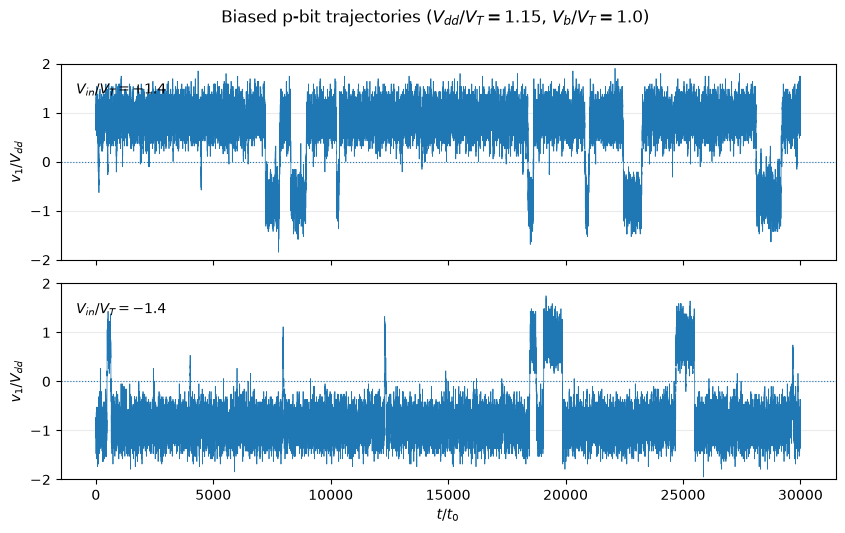

In [7]:
MAX_DISPLAY_POINTS = 250_000

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(10.0, 5.4),
    gridspec_kw={"hspace": 0.12},
)

for axis, run in zip(axes, biased_runs):
    time_over_t0 = run["time"] / T0
    v1_over_vdd = run["v1"] / VDD

    stride = max(
        1,
        len(time_over_t0) // MAX_DISPLAY_POINTS,
    )

    indices = np.arange(
        0,
        len(time_over_t0),
        stride,
    )

    if indices[-1] != len(time_over_t0) - 1:
        indices = np.append(
            indices,
            len(time_over_t0) - 1,
        )

    axis.plot(
        time_over_t0[indices],
        v1_over_vdd[indices],
        linewidth=0.55,
        rasterized=True,
    )

    axis.axhline(
        0.0,
        linestyle=":",
        linewidth=0.8,
    )

    axis.text(
        0.02,
        0.90,
        rf"$V_{{in}}/V_T={run['vin_over_vt']:+.1f}$",
        transform=axis.transAxes,
        va="top",
    )

    axis.set_ylabel(r"$v_1/V_{dd}$")
    axis.set_ylim(-2.0, 2.0)
    axis.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel(r"$t/t_0$")

fig.suptitle(
    rf"Biased p-bit trajectories "
    rf"($V_{{dd}}/V_T={VDD_OVER_VT}$, "
    rf"$V_b/V_T={VBIAS_OVER_VT}$)"
)

plt.tight_layout()
plt.show()

In [8]:
BURN_FRACTION = 0.10


def residence_weighted_voltage_distribution(run):
    time = np.asarray(
        run["time"],
        dtype=np.float64,
    )

    voltage = np.asarray(
        run["v1"][:-1],
        dtype=np.float64,
    )

    burn_time = (
        time[0]
        + BURN_FRACTION
        * (time[-1] - time[0])
    )

    residence_time = np.maximum(
        0.0,
        time[1:]
        - np.maximum(
            time[:-1],
            burn_time,
        ),
    )

    keep = residence_time > 0.0

    voltage = voltage[keep]
    residence_time = residence_time[keep]

    levels, inverse = np.unique(
        voltage,
        return_inverse=True,
    )

    probability = np.bincount(
        inverse,
        weights=residence_time,
    )

    probability /= probability.sum()

    return levels / VDD, probability


for run in biased_runs:
    (
        run["v1_levels_over_vdd"],
        run["v1_probability"],
    ) = residence_weighted_voltage_distribution(
        run
    )

/tmp/ipykernel_576529/4241586341.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


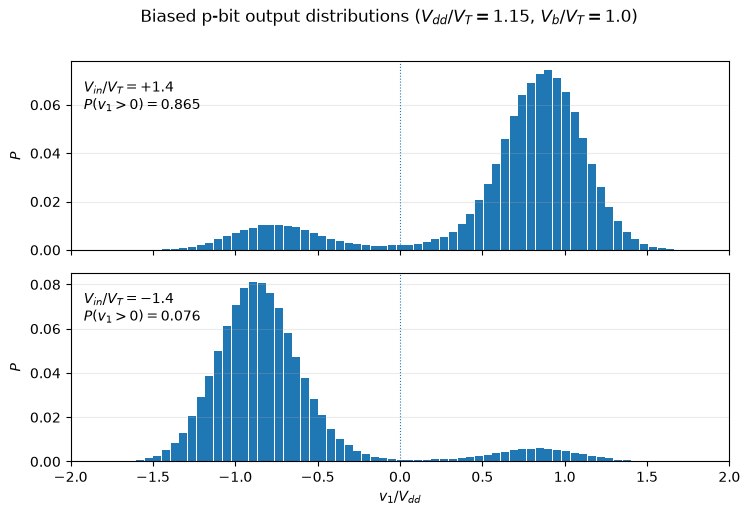

In [9]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(8.5, 5.2),
    gridspec_kw={"hspace": 0.12},
)

for axis, run in zip(axes, biased_runs):
    levels = run["v1_levels_over_vdd"]
    probability = run["v1_probability"]

    voltage_step = np.median(
        np.abs(np.diff(levels))
    )

    axis.bar(
        levels,
        probability,
        width=0.92 * voltage_step,
        align="center",
    )

    axis.axvline(
        0.0,
        linestyle=":",
        linewidth=0.8,
    )

    positive_probability = probability[
        levels > 0.0
    ].sum()

    axis.text(
        0.02,
        0.90,
        (
            rf"$V_{{in}}/V_T="
            rf"{run['vin_over_vt']:+.1f}$"
            "\n"
            rf"$P(v_1>0)={positive_probability:.3f}$"
        ),
        transform=axis.transAxes,
        va="top",
    )

    axis.set_ylabel(r"$P$")
    axis.set_ylim(bottom=0.0)
    axis.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel(r"$v_1/V_{dd}$")
axes[-1].set_xlim(-2.0, 2.0)

fig.suptitle(
    rf"Biased p-bit output distributions "
    rf"($V_{{dd}}/V_T={VDD_OVER_VT}$, "
    rf"$V_b/V_T={VBIAS_OVER_VT}$)"
)

plt.tight_layout()
plt.show()

In [11]:
# Figure 14(e) input sweep

VIN_SWEEP_OVER_VT = np.array(
    [
        -5.0,
        -4.0,
        -3.0,
        -2.0,
        -1.5,
        -1.1,
        -0.75,
        -0.50,
        -0.25,
         0.0,
         0.25,
         0.50,
         0.75,
         1.1,
         1.5,
         2.0,
         3.0,
         4.0,
         5.0,
    ],
    dtype=np.float64,
)


SWEEP_MAX_EVENTS = 1_500_000
SWEEP_BURN_FRACTION = 0.10
SWEEP_BASE_SEED = 4400

INSET_INPUTS = {
    -1.1,
    +1.1,
}

def sweep_duration(vin_over_vt):
    magnitude = abs(vin_over_vt)

    if magnitude >= 4.0:
        return 2.0e3 * T0

    if magnitude >= 3.0:
        return 5.0e3 * T0

    if magnitude >= 2.0:
        return 8.0e3 * T0

    return 1.5e4 * T0

def run_sigmoid_point(
    vin_over_vt,
    point_index,
):
    point_duration = sweep_duration(
        vin_over_vt
    )

    yaml_text = build_biased_pbit_yaml(
        vin_over_vt=float(vin_over_vt),
        t_finish=point_duration,
        seed=SWEEP_BASE_SEED + point_index,
    )

    netlist = SSEParser.parse_string(yaml_text)
    assembly = SSECompiler.compile_string(yaml_text)

    solver = GillespieSolver(
        netlist,
        assembly,
    )

    vr = regulated_voltage_vector(
        netlist,
        assembly,
    )

    node_capacitance = (
        2.0 * C_G
        + 3.0 * C_O
    )

    well_charge = int(
        np.rint(
            node_capacitance
            * VDD
            / E_CHARGE
        )
    )

    # Start in the input-favoured well.
    # At Vin = 0, alternate the initial well with the seed index.
    if vin_over_vt > 0.0:
        output_sign = +1

    elif vin_over_vt < 0.0:
        output_sign = -1

    else:
        output_sign = (
            +1
            if point_index % 2 == 0
            else -1
        )

    q_initial = np.array(
        [
            -output_sign * well_charge,
            +output_sign * well_charge,
        ],
        dtype=np.int64,
    )

    history = solver.simulate(
        q_init=q_initial,
        vr=vr,
        max_steps=SWEEP_MAX_EVENTS,
    )

    if not history["completed"]:
        raise RuntimeError(
            f"Vin/VT={vin_over_vt:+.2f} did not complete: "
            f"{history['termination_reason']}."
        )

    time = np.asarray(
        history["time"],
        dtype=np.float64,
    )

    v1 = np.asarray(
        history["potentials"]["v1"],
        dtype=np.float64,
    )

    burn_time = (
        time[0]
        + SWEEP_BURN_FRACTION
        * (time[-1] - time[0])
    )

    residence_time = np.maximum(
        0.0,
        time[1:]
        - np.maximum(
            time[:-1],
            burn_time,
        ),
    )

    positive_probability = (
        np.sum(
            residence_time[
                v1[:-1] > 0.0
            ]
        )
        / np.sum(residence_time)
    )

    result = {
        "vin_over_vt": float(vin_over_vt),
        "positive_probability": float(
            positive_probability
        ),
        "events": len(
            history["events"]["time"]
        ),
        "duration_over_t0": float(
            history["time"][-1] / T0
        ),
    }

    # Retain the complete state arrays only for the two inset cases.
    if np.isclose(
        abs(vin_over_vt),
        1.1,
        rtol=0.0,
        atol=1.0e-12,
    ):
        result["time"] = time.copy()
        result["charge"] = (
            history["charge"].copy()
        )
        result["assembly"] = assembly
        result["vr"] = vr.copy()

    del history
    gc.collect()

    return result


sigmoid_runs = [
    run_sigmoid_point(
        vin_over_vt,
        point_index,
    )
    for point_index, vin_over_vt
    in enumerate(VIN_SWEEP_OVER_VT)
]


for result in sigmoid_runs:
    print(
        f"Vin/VT={result['vin_over_vt']:+5.2f}: "
        f"P(v1>0)="
        f"{result['positive_probability']:.4f}, "
        f"duration/t0="
        f"{result['duration_over_t0']:,.0f}, "
        f"events={result['events']:,}"
    )

Vin/VT=-5.00: P(v1>0)=0.0002, duration/t0=2,000, events=234,106
Vin/VT=-4.00: P(v1>0)=0.0001, duration/t0=2,000, events=133,126
Vin/VT=-3.00: P(v1>0)=0.0004, duration/t0=5,000, events=233,398
Vin/VT=-2.00: P(v1>0)=0.0008, duration/t0=8,000, events=322,041
Vin/VT=-1.50: P(v1>0)=0.0576, duration/t0=15,000, events=569,426
Vin/VT=-1.10: P(v1>0)=0.0537, duration/t0=15,000, events=553,952
Vin/VT=-0.75: P(v1>0)=0.1150, duration/t0=15,000, events=540,152
Vin/VT=-0.50: P(v1>0)=0.1540, duration/t0=15,000, events=542,939
Vin/VT=-0.25: P(v1>0)=0.3208, duration/t0=15,000, events=533,811
Vin/VT=+0.00: P(v1>0)=0.4220, duration/t0=15,000, events=537,378
Vin/VT=+0.25: P(v1>0)=0.1495, duration/t0=15,000, events=530,294
Vin/VT=+0.50: P(v1>0)=0.6256, duration/t0=15,000, events=531,647
Vin/VT=+0.75: P(v1>0)=0.6935, duration/t0=15,000, events=527,079
Vin/VT=+1.10: P(v1>0)=0.8565, duration/t0=15,000, events=533,605
Vin/VT=+1.50: P(v1>0)=0.9117, duration/t0=15,000, events=530,788
Vin/VT=+2.00: P(v1>0)=0.9927,

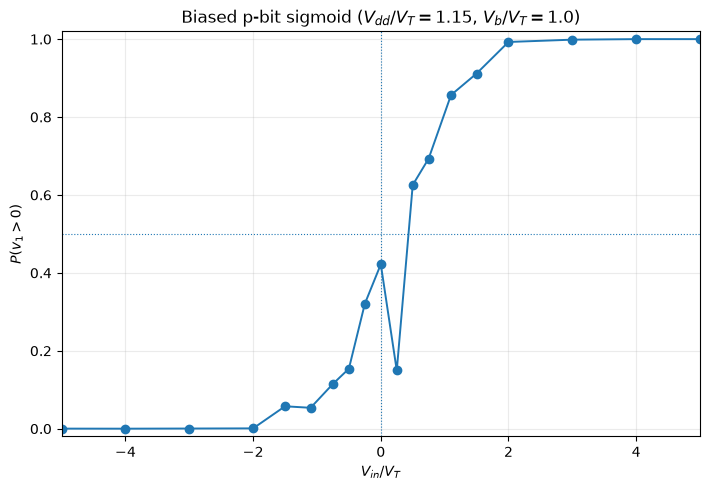

In [12]:
vin_values = np.array(
    [run["vin_over_vt"] for run in sigmoid_runs],
    dtype=np.float64,
)

positive_probabilities = np.array(
    [run["positive_probability"] for run in sigmoid_runs],
    dtype=np.float64,
)

sort_index = np.argsort(vin_values)

vin_values = vin_values[sort_index]
positive_probabilities = positive_probabilities[sort_index]

fig, axis = plt.subplots(
    figsize=(7.2, 5.0),
)

axis.plot(
    vin_values,
    positive_probabilities,
    marker="o",
    linewidth=1.4,
)

axis.axhline(
    0.5,
    linestyle=":",
    linewidth=0.8,
)

axis.axvline(
    0.0,
    linestyle=":",
    linewidth=0.8,
)

axis.set_xlabel(r"$V_{in}/V_T$")
axis.set_ylabel(r"$P(v_1 > 0)$")

axis.set_title(
    rf"Biased p-bit sigmoid "
    rf"($V_{{dd}}/V_T={VDD_OVER_VT}$, "
    rf"$V_b/V_T={VBIAS_OVER_VT}$)"
)

axis.set_xlim(vin_values.min(), vin_values.max())
axis.set_ylim(-0.02, 1.02)
axis.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [13]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def centers_to_edges(centers):
    centers = np.asarray(centers, dtype=np.float64)

    if len(centers) < 2:
        raise ValueError("Need at least two centers.")

    midpoints = 0.5 * (centers[:-1] + centers[1:])

    return np.concatenate(
        [
            [centers[0] - 0.5 * (centers[1] - centers[0])],
            midpoints,
            [centers[-1] + 0.5 * (centers[-1] - centers[-2])],
        ]
    )


def build_inset_distribution(run, burn_fraction=SWEEP_BURN_FRACTION):
    time = np.asarray(run["time"], dtype=np.float64)
    charge = np.asarray(run["charge"], dtype=np.int64)

    assembly = run["assembly"]
    vr = run["vr"]

    burn_time = (
        time[0]
        + burn_fraction * (time[-1] - time[0])
    )

    residence_time = np.maximum(
        0.0,
        time[1:] - np.maximum(time[:-1], burn_time),
    )

    keep = residence_time > 0.0

    index_v1 = assembly.free_names.index("v1")
    index_v2 = assembly.free_names.index("v2")

    q1 = charge[:-1, index_v1][keep]
    q2 = charge[:-1, index_v2][keep]
    residence_time = residence_time[keep]

    q1_levels = np.arange(q1.min(), q1.max() + 1, dtype=np.int64)
    q2_levels = np.arange(q2.min(), q2.max() + 1, dtype=np.int64)

    probability = np.zeros(
        (len(q2_levels), len(q1_levels)),
        dtype=np.float64,
    )

    np.add.at(
        probability,
        (
            q2 - q2_levels[0],
            q1 - q1_levels[0],
        ),
        residence_time,
    )

    probability /= probability.sum()

    voltage_offset = (
        -assembly.C_inv @ assembly.Cx @ vr
    )

    v1_centers = (
        voltage_offset[index_v1]
        - E_CHARGE
        * assembly.C_inv[index_v1, index_v1]
        * q1_levels
    ) / V_THERMAL

    v2_centers = (
        voltage_offset[index_v2]
        - E_CHARGE
        * assembly.C_inv[index_v2, index_v2]
        * q2_levels
    ) / V_THERMAL

    # Reverse so the plotted axes increase normally.
    v1_centers = v1_centers[::-1]
    v2_centers = v2_centers[::-1]
    probability = probability[::-1, ::-1]

    return {
        "vin_over_vt": run["vin_over_vt"],
        "v1_edges": centers_to_edges(v1_centers),
        "v2_edges": centers_to_edges(v2_centers),
        "probability": probability,
    }


inset_runs = {
    run["vin_over_vt"]: build_inset_distribution(run)
    for run in sigmoid_runs
    if "charge" in run
}

print("Inset cases prepared:", sorted(inset_runs.keys()))

Inset cases prepared: [-1.1, 1.1]


/tmp/ipykernel_576529/3943857805.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


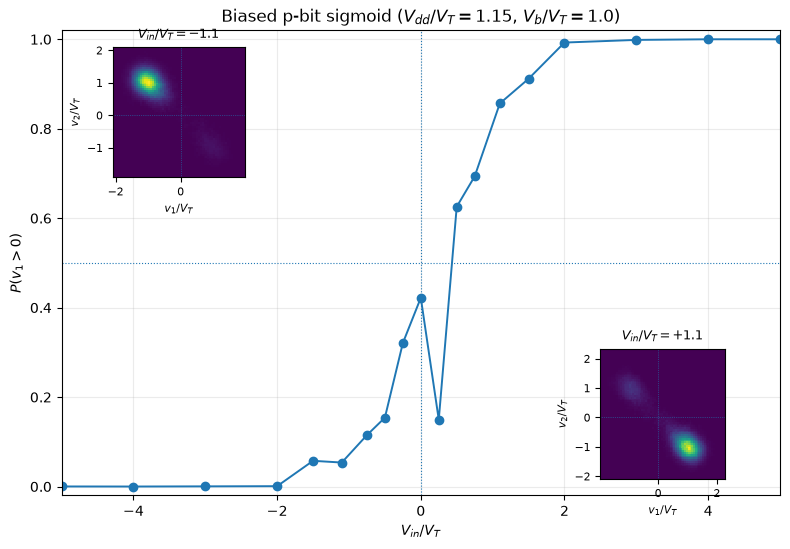

In [14]:
vin_values = np.array(
    [run["vin_over_vt"] for run in sigmoid_runs],
    dtype=np.float64,
)

positive_probabilities = np.array(
    [run["positive_probability"] for run in sigmoid_runs],
    dtype=np.float64,
)

sort_index = np.argsort(vin_values)
vin_values = vin_values[sort_index]
positive_probabilities = positive_probabilities[sort_index]

fig, axis = plt.subplots(figsize=(8.0, 5.6))

axis.plot(
    vin_values,
    positive_probabilities,
    marker="o",
    linewidth=1.4,
)

axis.axhline(0.5, linestyle=":", linewidth=0.8)
axis.axvline(0.0, linestyle=":", linewidth=0.8)

axis.set_xlabel(r"$V_{in}/V_T$")
axis.set_ylabel(r"$P(v_1 > 0)$")

axis.set_title(
    rf"Biased p-bit sigmoid "
    rf"($V_{{dd}}/V_T={VDD_OVER_VT}$, "
    rf"$V_b/V_T={VBIAS_OVER_VT}$)"
)

axis.set_xlim(vin_values.min(), vin_values.max())
axis.set_ylim(-0.02, 1.02)
axis.grid(alpha=0.25)

# Left inset: Vin/VT = -1.1
left_inset = inset_axes(
    axis,
    width="28%",
    height="28%",
    loc="upper left",
    borderpad=1.2,
)

left_data = inset_runs[-1.1]
left_mesh = left_inset.pcolormesh(
    left_data["v1_edges"],
    left_data["v2_edges"],
    left_data["probability"],
    shading="flat",
)

left_inset.axhline(0.0, linestyle=":", linewidth=0.5)
left_inset.axvline(0.0, linestyle=":", linewidth=0.5)
left_inset.set_title(r"$V_{in}/V_T=-1.1$", fontsize=9)
left_inset.set_xlabel(r"$v_1/V_T$", fontsize=8)
left_inset.set_ylabel(r"$v_2/V_T$", fontsize=8)
left_inset.tick_params(labelsize=8)
left_inset.set_aspect("equal")

# Right inset: Vin/VT = +1.1
right_inset = inset_axes(
    axis,
    width="28%",
    height="28%",
    loc="lower right",
    borderpad=1.2,
)

right_data = inset_runs[1.1]
right_mesh = right_inset.pcolormesh(
    right_data["v1_edges"],
    right_data["v2_edges"],
    right_data["probability"],
    shading="flat",
)

right_inset.axhline(0.0, linestyle=":", linewidth=0.5)
right_inset.axvline(0.0, linestyle=":", linewidth=0.5)
right_inset.set_title(r"$V_{in}/V_T=+1.1$", fontsize=9)
right_inset.set_xlabel(r"$v_1/V_T$", fontsize=8)
right_inset.set_ylabel(r"$v_2/V_T$", fontsize=8)
right_inset.tick_params(labelsize=8)
right_inset.set_aspect("equal")

plt.tight_layout()
plt.show()